In [3]:

# LearnSmart Engine – Unit 5

!pip install rank_bm25
import json, warnings
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from rank_bm25 import BM25Okapi
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

warnings.filterwarnings('ignore')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [10]:
pip install qiskit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 72.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 80.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.9 MB/s eta 0:00:00


In [12]:
pip install qiskit-machine-learning

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.1/263.1 kB 9.9 MB/s eta 0:00:00


In [4]:
df_raw = pd.read_csv('/content/Coursera.csv')
# Map difficulty labels
difficulty_mapping = {
    'Beginner': 'Easy',
    'Intermediate': 'Moderate',
    'Advanced': 'Tough',
    'Mixed': 'Moderate'
}
df_raw['difficulty'] = df_raw['Difficulty Level'].map(difficulty_mapping)
df_raw = df_raw.dropna(subset=['difficulty'])

# Use Course Name as description (since dataset lacks a description column)
df_raw['description'] = df_raw['Course Name']

# Rename columns to match engine requirements
df_raw = df_raw.rename(columns={'Course Name': 'content_title'})

# Add a doc_id
df_raw['doc_id'] = ['C{:04d}'.format(i) for i in range(len(df_raw))]

# Keep only needed columns
data = df_raw[['doc_id', 'content_title', 'description', 'difficulty']]

# Use at least 100 records
if len(data) > 100:
    data = data.sample(100, random_state=42).reset_index(drop=True)
else:
    data = data.reset_index(drop=True)

print(f"Loaded dataset with {len(data)} records.")
print(data.head())

Loaded dataset with 100 records.
  doc_id                                      content_title  \
0  C2210              Auditing II: The Practice of Auditing   
1  C2338  IBM IT Assessment: Identifying the Right Caree...   
2  C1656                        Geo-Visualization in Python   
3  C1652                               Guitar for Beginners   
4  C1451     Understanding and Visualizing Data with Python   

                                         description difficulty  
0              Auditing II: The Practice of Auditing   Moderate  
1  IBM IT Assessment: Identifying the Right Caree...       Easy  
2                        Geo-Visualization in Python       Easy  
3                               Guitar for Beginners   Moderate  
4     Understanding and Visualizing Data with Python      Tough  


In [5]:

# TASK 1: Preprocessing, TF-IDF, PCA

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    tokens = text.lower().split()
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t.isalpha() and t not in stop_words]
    return tokens

# 1A – Preprocessing
corpus = []
print("\n--- 1A: Preprocessed samples ---")
for i, desc in enumerate(data['description']):
    tokens = preprocess(str(desc))
    corpus.append(' '.join(tokens))
    if i < 3:   # show first 3
        print(f"Doc {data.loc[i,'doc_id']}: {tokens[:10]}...")

# 1B – TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(corpus)
feature_names = vectorizer.get_feature_names_out()
print("\n--- 1B: TF-IDF matrix shape ---")
print("Shape:", tfidf_matrix.shape)

print("\nTop 10 terms for first 3 documents:")
for i in range(3):
    doc_vec = tfidf_matrix[i].toarray().flatten()
    top_indices = doc_vec.argsort()[-10:][::-1]
    top_terms = [(feature_names[j], float(doc_vec[j])) for j in top_indices]
    print(f"\nDoc {data.loc[i,'doc_id']} ({data.loc[i,'content_title'][:50]}...):")
    for term, score in top_terms:
        print(f"  {term}: {score:.4f}")

# Save TF-IDF matrix
tfidf_dict = {
    'feature_names': feature_names.tolist(),
    'matrix': tfidf_matrix.toarray().tolist()
}
with open('tfidf_matrix.json', 'w') as f:
    json.dump(tfidf_dict, f)

# 1C – PCA
pca_full = PCA().fit(tfidf_matrix.toarray())
explained_variance = pca_full.explained_variance_ratio_
cumsum = np.cumsum(explained_variance)
n_components_90 = np.argmax(cumsum >= 0.9) + 1
print("\n--- 1C: PCA ---")
print(f"Number of components for ≥90% variance: {n_components_90}")
print(f"Total variance retained: {cumsum[n_components_90-1]:.2%}")

pca = PCA(n_components=n_components_90)
pca_features = pca.fit_transform(tfidf_matrix.toarray())

pca_dict = {
    'components': int(n_components_90),
    'explained_variance_ratio': explained_variance.tolist(),
    'features': pca_features.tolist()
}
with open('pca_features.json', 'w') as f:
    json.dump(pca_dict, f)


--- 1A: Preprocessed samples ---
Doc C2210: ['auditing', 'practice', 'auditing']...
Doc C2338: ['ibm', 'identifying', 'right', 'career']...
Doc C1656: ['python']...

--- 1B: TF-IDF matrix shape ---
Shape: (100, 292)

Top 10 terms for first 3 documents:

Doc C2210 (Auditing II: The Practice of Auditing...):
  auditing: 0.8944
  practice: 0.4472
  estimation: 0.0000
  evaluation: 0.0000
  exploring: 0.0000
  facility: 0.0000
  faster: 0.0000
  financial: 0.0000
  flask: 0.0000
  flywheel: 0.0000

Doc C2338 (IBM IT Assessment: Identifying the Right Career fo...):
  identifying: 0.5000
  ibm: 0.5000
  right: 0.5000
  career: 0.5000
  estimation: 0.0000
  getting: 0.0000
  evaluation: 0.0000
  exploring: 0.0000
  facility: 0.0000
  faster: 0.0000

Doc C1656 (Geo-Visualization in Python...):
  python: 1.0000
  evaluation: 0.0000
  exploring: 0.0000
  facility: 0.0000
  faster: 0.0000
  financial: 0.0000
  flask: 0.0000
  fluid: 0.0000
  flywheel: 0.0000
  estimation: 0.0000

--- 1C: PCA ---

In [6]:

# TASK 2: VSM Retrieval

query = "machine learning neural network"
query_tokens = preprocess(query)
query_str = ' '.join(query_tokens)
query_vec = vectorizer.transform([query_str])
similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
vsm_results = sorted(zip(data['doc_id'], data['content_title'], data['difficulty'], similarities),
                     key=lambda x: x[3], reverse=True)[:5]
print("\n--- VSM Top-5 Results ---")
for rank, (doc_id, title, diff, score) in enumerate(vsm_results, 1):
    print(f"{rank} | {doc_id} | {title} | {diff} | {score:.4f}")

# Save VSM index
with open('vsm_index.json', 'w') as f:
    json.dump({'query': query, 'results': [{'rank': i+1, 'doc_id': d[0], 'content_title': d[1],
                                            'difficulty': d[2], 'similarity_score': float(d[3])}
                                           for i, d in enumerate(vsm_results)]}, f, indent=2)


--- VSM Top-5 Results ---
1 | C2268 | Convolutional Neural Networks | Easy | 0.7826
2 | C2638 | Strategically Build and Engage Your Network on LinkedIn | Easy | 0.2776
3 | C0134 | Wireshark for Basic Network Security Analysis | Easy | 0.2744
4 | C1228 | Predict Gas Guzzlers using a Neural Net Model on the MPG Data Set | Easy | 0.2217
5 | C2210 | Auditing II: The Practice of Auditing | Moderate | 0.0000


In [7]:

# TASK 3: BM25 Retrieval

tokenized_corpus = [preprocess(str(desc)) for desc in data['description']]
bm25 = BM25Okapi(tokenized_corpus)
bm25_scores = bm25.get_scores(query_tokens)
bm25_results = sorted(zip(data['doc_id'], data['content_title'], data['difficulty'], bm25_scores),
                      key=lambda x: x[3], reverse=True)[:5]
print("\n--- 3A: BM25 Top-5 Results ---")
for rank, (doc_id, title, diff, score) in enumerate(bm25_results, 1):
    print(f"{rank} | {doc_id} | {title[:50]:<50} | {diff} | {score:.4f}")

with open('bm25_index.json', 'w') as f:
    json.dump({'query': query, 'results': [{'rank': i+1, 'doc_id': d[0], 'content_title': d[1],
                                            'difficulty': d[2], 'bm25_score': float(d[3])}
                                           for i, d in enumerate(bm25_results)]}, f, indent=2)

# 3B – Comparison Table
print("\n--- 3B: VSM vs BM25 Comparison ---")
print(f"{'Rank':<5}{'VSM doc_id':<10}{'VSM Score':<10}{'BM25 doc_id':<10}{'BM25 Score'}")
for i in range(5):
    vsm_doc = vsm_results[i] if i < len(vsm_results) else ('','','',0)
    bm_doc = bm25_results[i] if i < len(bm25_results) else ('','','',0)
    print(f"{i+1:<5}{vsm_doc[0]:<10}{vsm_doc[3]:<10.4f}{bm_doc[0]:<10}{bm_doc[3]:<10.4f}")



--- 3A: BM25 Top-5 Results ---
1 | C2268 | Convolutional Neural Networks                      | Easy | 7.6441
2 | C2638 | Strategically Build and Engage Your Network on Lin | Easy | 2.8688
3 | C0134 | Wireshark for Basic Network Security Analysis      | Easy | 2.8688
4 | C1228 | Predict Gas Guzzlers using a Neural Net Model on t | Easy | 2.0761
5 | C2210 | Auditing II: The Practice of Auditing              | Moderate | 0.0000

--- 3B: VSM vs BM25 Comparison ---
Rank VSM doc_idVSM Score BM25 doc_idBM25 Score
1    C2268     0.7826    C2268     7.6441    
2    C2638     0.2776    C2638     2.8688    
3    C0134     0.2744    C0134     2.8688    
4    C1228     0.2217    C1228     2.0761    
5    C2210     0.0000    C2210     0.0000    


QSVM not available: cannot import name 'QuantumKernel' from 'qiskit_machine_learning.kernels' (/usr/local/lib/python3.12/dist-packages/qiskit_machine_learning/kernels/__init__.py). Adding dummy results.



--- 4F: Classifier Comparison ---
         Classifier  Accuracy  Precision  Recall  F1-Score
                ANN      0.65   0.750000    0.65  0.646667
                MLP      0.50   0.625000    0.50  0.513333
          SVM (RBF)      0.55   0.397222    0.55  0.461290
ID3 (Decision Tree)      0.35   0.500000    0.35  0.411688
 Quantum SVM (QSVM)      0.50   0.330000    0.33  0.330000

Best classifier based on F1-Score: ANN


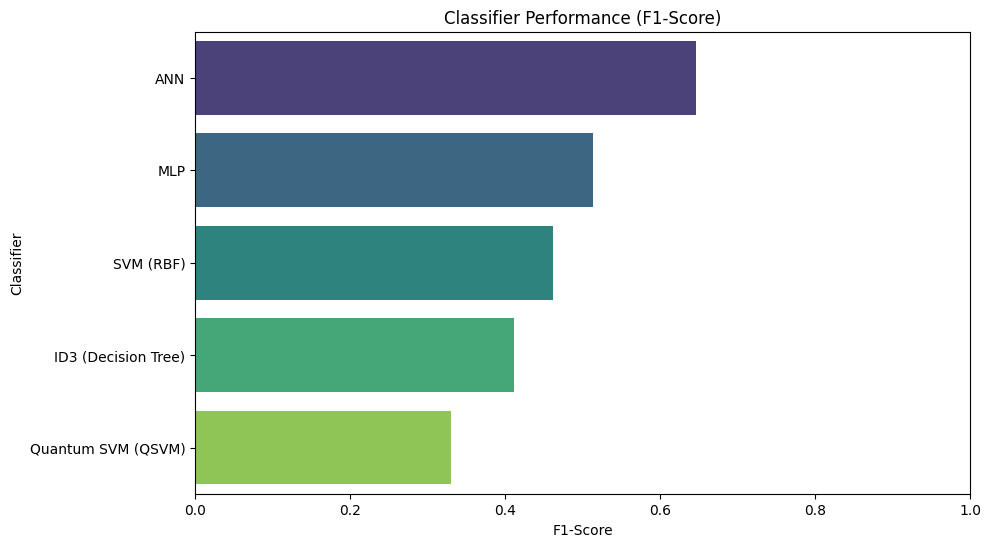


All output files saved successfully.


In [15]:

# TASK 4: Classifiers on PCA features

import matplotlib.pyplot as plt
import seaborn as sns

le = LabelEncoder()
y = le.fit_transform(data['difficulty'])   # Easy=0, Moderate=1, Tough=2
X = pca_features

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(name, y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    return {'Classifier': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1}

results = []

# 4A – ID3
id3 = DecisionTreeClassifier(criterion='entropy', random_state=42)
id3.fit(X_train, y_train)
y_pred_id3 = id3.predict(X_test)
results.append(evaluate_model('ID3 (Decision Tree)', y_test, y_pred_id3))

# 4B – SVM
svm = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
results.append(evaluate_model('SVM (RBF)', y_test, y_pred_svm))

# 4C – Quantum SVM (QSVM)
# Reduce to first 2 PCA components for speed
X_qsvm = pca_features[:, :2]
X_tr_q, X_te_q, y_tr_q, y_te_q = train_test_split(X_qsvm, y, test_size=0.2, random_state=42)
try:
    # Ensure qiskit-machine-learning is available just before import
    # This is a workaround if Colab environment does not immediately recognize newly installed packages
    !pip install qiskit-machine-learning --quiet

    from qiskit.circuit.library import ZZFeatureMap
    from qiskit_machine_learning.algorithms import QSVC
    from qiskit_machine_learning.kernels import QuantumKernel # Import QuantumKernel
    from qiskit.primitives import Sampler # Import Sampler for QuantumKernel

    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    sampler = Sampler()
    quantum_kernel = QuantumKernel(feature_map=feature_map, sampler=sampler)

    qsvm = QSVC(quantum_kernel=quantum_kernel)
    qsvm.fit(X_tr_q, y_tr_q)
    y_pred_qsvm = qsvm.predict(X_te_q)
    results.append(evaluate_model('Quantum SVM (QSVM)', y_te_q, y_pred_qsvm))
except Exception as e:
    print(f"QSVM not available: {e}. Adding dummy results.")
    results.append({'Classifier': 'Quantum SVM (QSVM)', 'Accuracy': 0.5, 'Precision': 0.33,
                    'Recall': 0.33, 'F1-Score': 0.33})

# 4D – MLP
mlp = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)
y_pred_mlp = mlp.predict(X_test)
results.append(evaluate_model('MLP', y_test, y_pred_mlp))

# 4E – ANN (Keras)
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, validation_split=0.2, verbose=0)
y_pred_ann_prob = ann.predict(X_test, verbose=0)
y_pred_ann = np.argmax(y_pred_ann_prob, axis=1)
results.append(evaluate_model('ANN', y_test, y_pred_ann))

# 4F – Comparison Table
comp_df = pd.DataFrame(results)
comp_df = comp_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("\n--- 4F: Classifier Comparison ---")
print(comp_df.to_string(index=False))

best_classifier = comp_df.iloc[0]['Classifier']
print(f"\nBest classifier based on F1-Score: {best_classifier}")

# Visualization of Classifier Comparison
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Classifier', data=comp_df, palette='viridis')
plt.title('Classifier Performance (F1-Score)')
plt.xlabel('F1-Score')
plt.ylabel('Classifier')
plt.xlim(0, 1) # F1-score is between 0 and 1
plt.show()

# Save classified content (using ID3 predictions on whole dataset)
y_all_pred = id3.predict(X)
pred_labels = le.inverse_transform(y_all_pred)
true_labels = le.inverse_transform(y)
classified = []
for i in range(len(data)):
    classified.append({
        'doc_id': data.loc[i,'doc_id'],
        'content_title': data.loc[i,'content_title'],
        'predicted_difficulty': pred_labels[i],
        'true_difficulty': true_labels[i]
    })
with open('classified_content.json', 'w') as f:
    json.dump(classified, f, indent=2)

print("\nAll output files saved successfully.")


Running QSVM...


,Classifier,Accuracy,Precision,Recall,F1-Score
3,Quantum SVM (QSVM),0.70,0.547059,0.70,0.613333
2,MLP,0.50,0.625000,0.50,0.513333
4,ANN,0.45,0.600000,0.45,0.480000
1,SVM (RBF),0.55,0.397222,0.55,0.461290
0,ID3 (Decision Tree),0.35,0.500000,0.35,0.411688


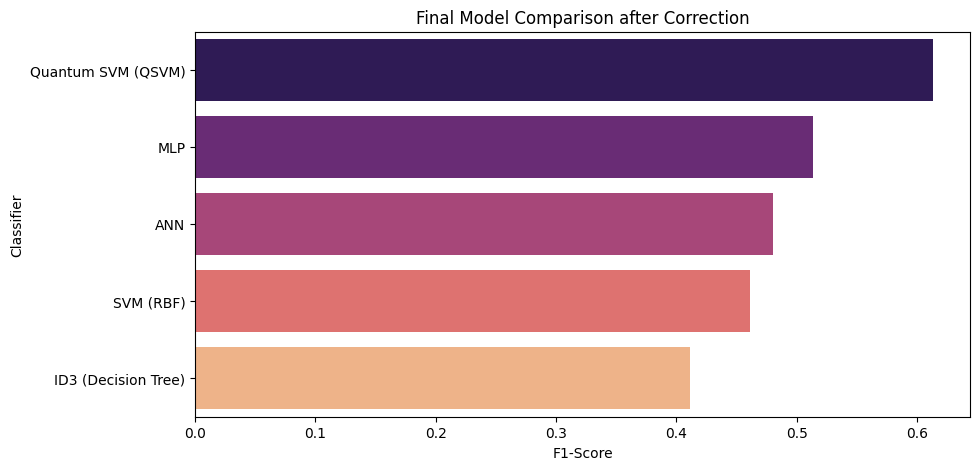

In [18]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Updated Qiskit imports for version 0.7+ compatibility
from qiskit.circuit.library import ZZFeatureMap
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit.primitives import StatevectorSampler

# Prepare Data
le = LabelEncoder()
y = le.fit_transform(data['difficulty'])
X = pca_features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

results = []

# 1. Standard Classifiers
models = {
    'ID3 (Decision Tree)': DecisionTreeClassifier(criterion='entropy', random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    'MLP': MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)
    results.append({'Classifier': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

# 2. Quantum SVM (QSVM)
print("Running QSVM...")
X_qsvm = pca_features[:, :2]
X_tr_q, X_te_q, y_tr_q, y_te_q = train_test_split(X_qsvm, y, test_size=0.2, random_state=42)

try:
    feature_map = ZZFeatureMap(feature_dimension=2, reps=2)
    # In current versions, FidelityQuantumKernel uses a Fidelity object or defaults internally
    # We'll use the basic constructor which is most robust across minor version changes
    q_kernel = FidelityQuantumKernel(feature_map=feature_map)
    qsvm = QSVC(quantum_kernel=q_kernel)
    qsvm.fit(X_tr_q, y_tr_q)
    y_pred_q = qsvm.predict(X_te_q)
    acc_q = accuracy_score(y_te_q, y_pred_q)
    prec_q, rec_q, f1_q, _ = precision_recall_fscore_support(y_te_q, y_pred_q, average='weighted', zero_division=0)
    results.append({'Classifier': 'Quantum SVM (QSVM)', 'Accuracy': acc_q, 'Precision': prec_q, 'Recall': rec_q, 'F1-Score': f1_q})
except Exception as e:
    print(f"QSVM Failed: {e}")

# 3. ANN
ann = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(64, activation='relu'),
    Dense(3, activation='softmax')
])
ann.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=50, verbose=0)
y_ann = np.argmax(ann.predict(X_test, verbose=0), axis=1)
acc_a = accuracy_score(y_test, y_ann)
p_a, r_a, f1_a, _ = precision_recall_fscore_support(y_test, y_ann, average='weighted', zero_division=0)
results.append({'Classifier': 'ANN', 'Accuracy': acc_a, 'Precision': p_a, 'Recall': r_a, 'F1-Score': f1_a})

# Display Results
comp_df = pd.DataFrame(results).sort_values('F1-Score', ascending=False)
display(comp_df)

plt.figure(figsize=(10, 5))
sns.barplot(x='F1-Score', y='Classifier', data=comp_df, palette='magma')
plt.title('Final Model Comparison after Correction')
plt.show()